In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

Demo analizy składowych głównych (Principal Component Analysis) na ćwiczebnym zbiorze danych
--------------------------------------------------------------------------------------------

Funkcje generujące dane:

In [2]:
def data_line(n=42, noise=0):
    xa, xb = np.array([-1, 2, 3]), np.array([4, -9, 0])
    data = np.array([xa + r * (xb - xa) for r in np.random.rand(n)])
    data += noise * np.random.randn(*data.shape)
    return data


def data_triangle(n=500, noise=0):
    xa, xb, xc = np.array([-1, 2, 3]), np.array([4, -9, 0]), \
        np.array([1, 20, 0])
    data = []
    for r in np.random.rand(n, 3):
        r /= np.sum(r)
        x = np.sum([ri * xi for ri, xi in zip(r, [xa, xb, xc])], axis=0)
        data.append(x)
    data = np.array(data)
    data += noise * np.random.randn(*data.shape)
    return data

Funkcja wyświetlająca dane:

In [3]:
def pca_show(data, title, indexes=[0, 1, 2], whiten=False):
    from mpl_toolkits.mplot3d import Axes3D
    pca = PCA(3, whiten=whiten).fit(data)
    data_pca = pca.transform(data)
    
    plt.figure(title, figsize=(12, 5))
    ax = plt.gcf().add_subplot(131, projection='3d')
    i, j, k = indexes
    ax.scatter(data[:, i], data[:, j], data[:, k], c='k')
    ax.set_xlabel('data[:, {}]'.format(i))
    ax.set_ylabel('data[:, {}]'.format(j))
    ax.set_zlabel('data[:, {}]'.format(k))
    plt.title('Original data (3D) view')
    plt.subplot(132)
    plt.scatter(data_pca[:, 0], data_pca[:, 1], c='k', alpha=0.5)    
    plt.axis('equal')
    plt.xlabel('1st PCA component')
    plt.ylabel('2nd PCA component')
    plt.title('PCA projection')
    plt.subplot(133)
    plt.plot(range(1, 4), pca.explained_variance_ratio_, 'ko-')
    plt.xlabel('ID of component')
    plt.ylabel('% of variance explained')
    plt.title('EVR: {}'.format(np.round(pca.explained_variance_ratio_, 3)))
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


Dane jednowymiarowe (na linii), zatopione w 3 wymiarach:

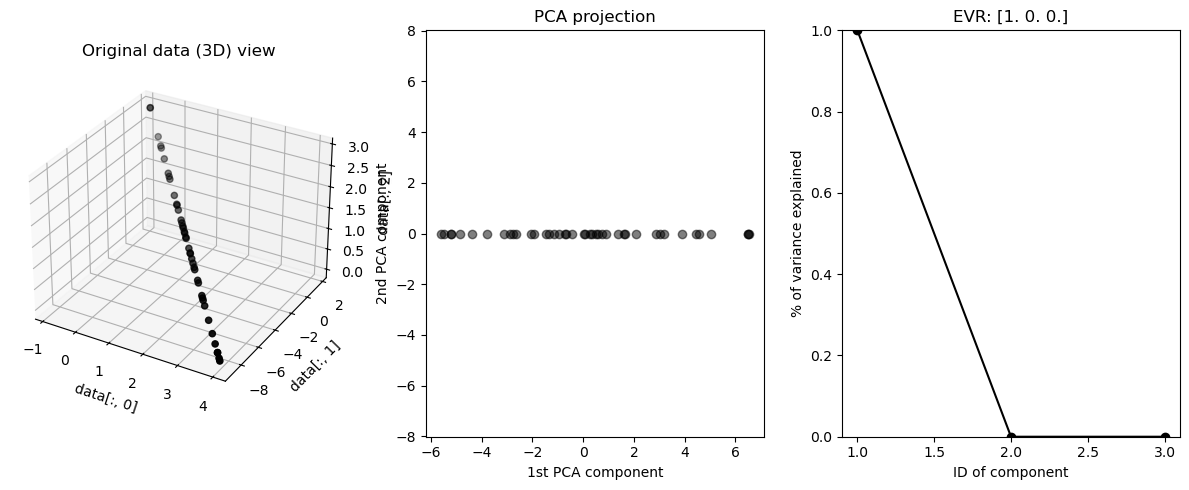

In [5]:
pca_show(data_line(), 'Line')

Dane z dominującym wymiarem (np. jednowymiarowe zaszumione):

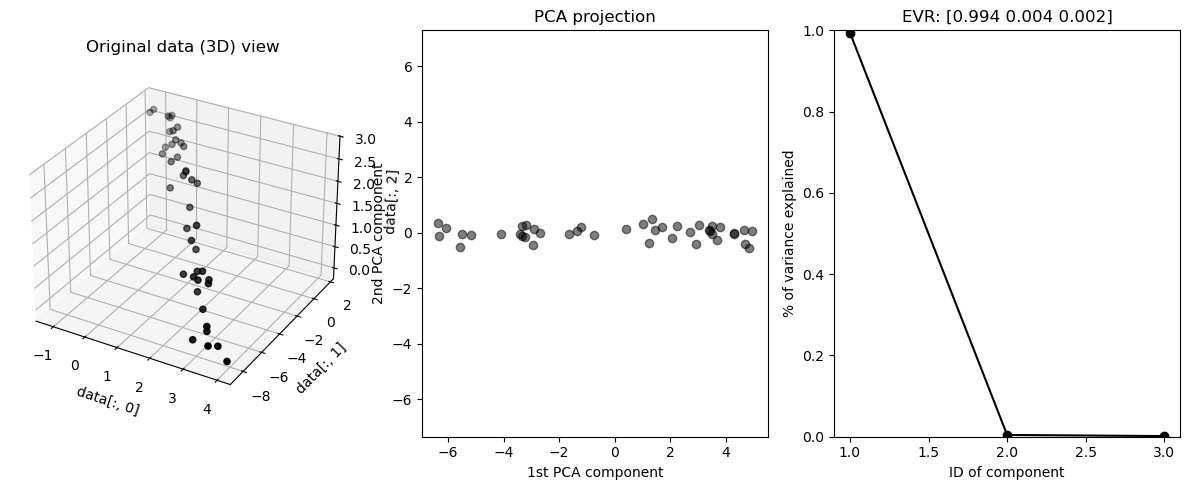

In [6]:
pca_show(data_line(noise=0.2), 'Line, noise=0.2')

Dane wielowymiarowe, z dominującym wymiarem (np. nieprzeskalowane cechy):

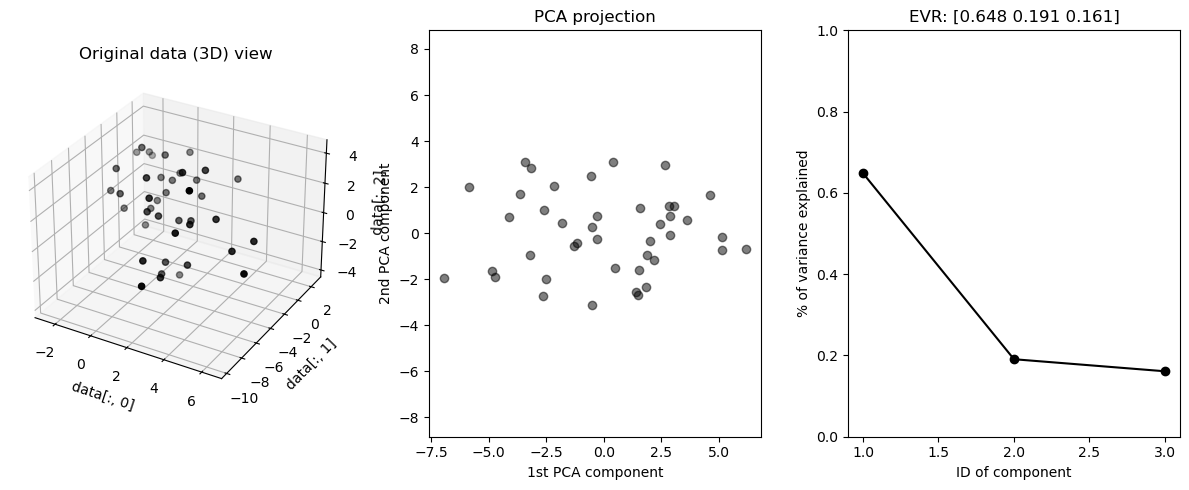

In [7]:
pca_show(data_line(noise=2), 'Line, noise=2')

Dane dwuwymiarowe (simpleks), zatopione w 3 wymiarach:

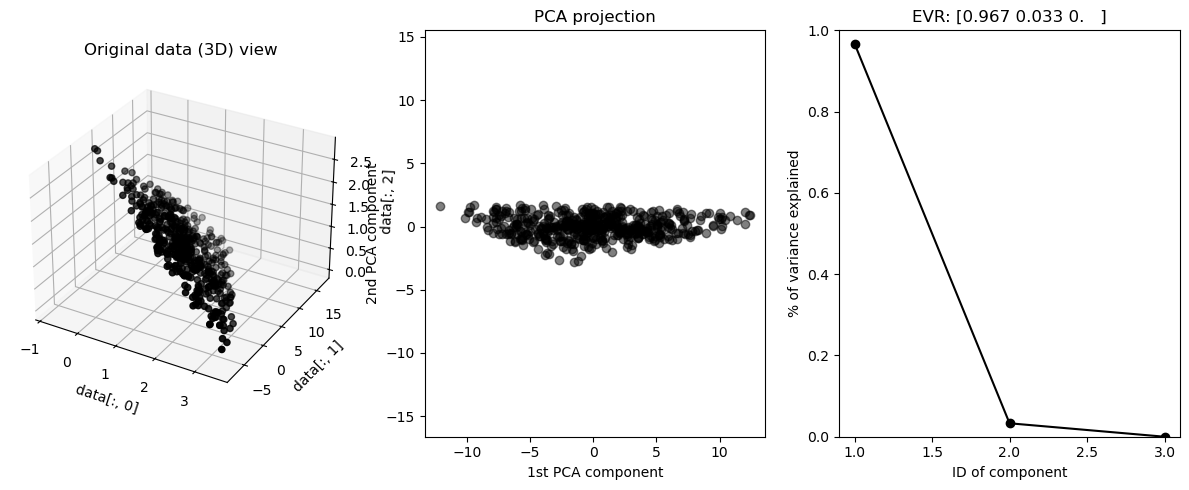

In [8]:
pca_show(data_triangle(), 'Triangle')

Dane wielowymiarowe (np. dwuwymiarowe zaszumione):

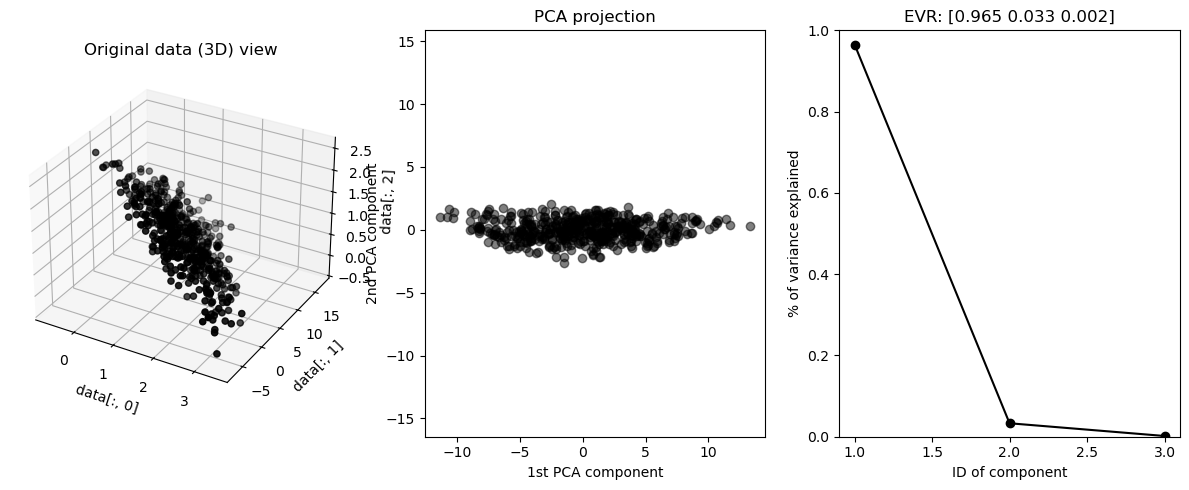

In [9]:
pca_show(data_triangle(noise=0.2), 'Triangle, noise=0.2')

Dane wielowymiarowe (np. z dominującymi dwoma wymiarami):

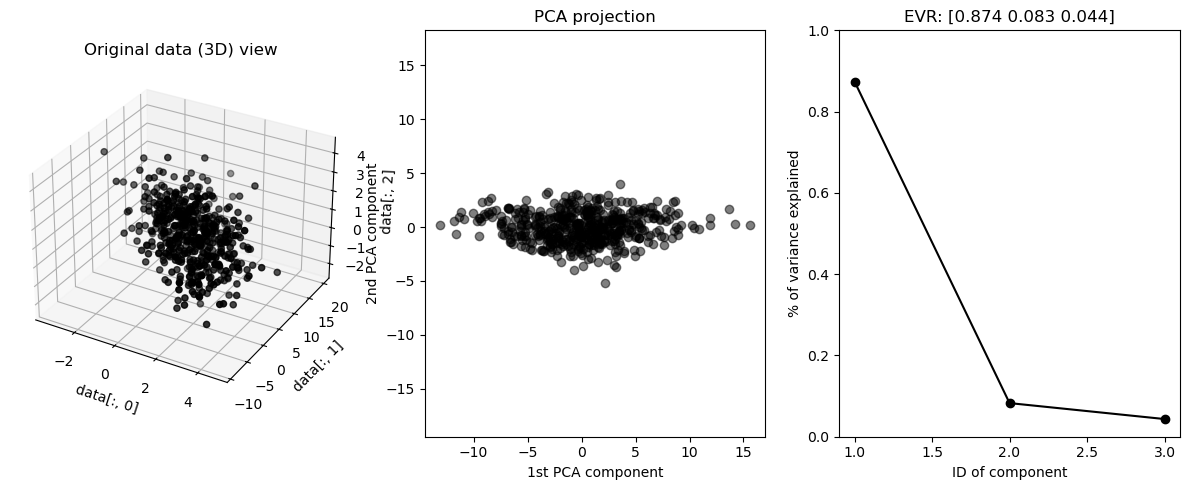

In [10]:
pca_show(data_triangle(noise=1), 'Triangle, noise=1')

Dane wielowymiarowe (duży szum lub 3 wymiary):

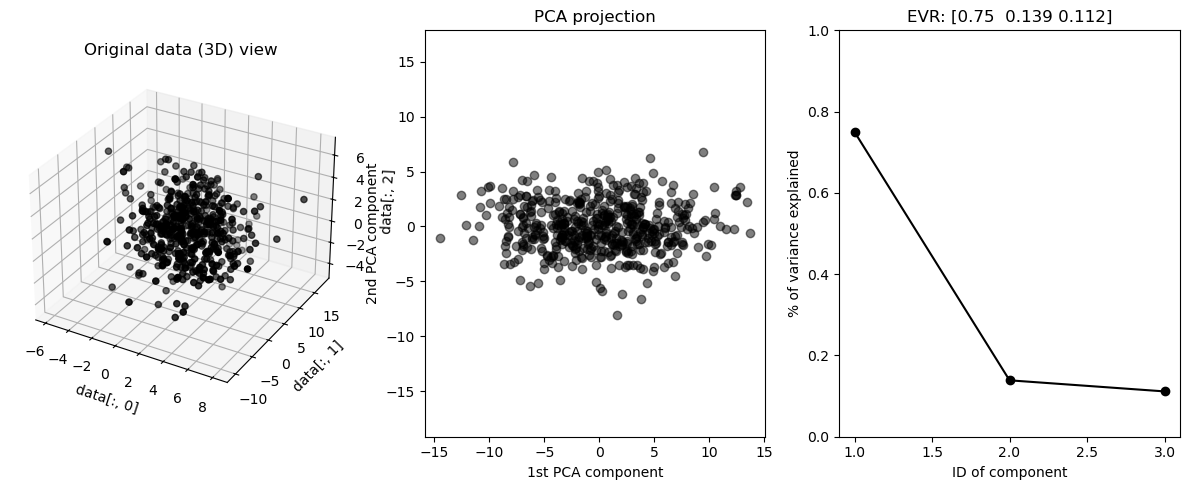

In [11]:
pca_show(data_triangle(noise=2), 'Triangle, noise=2')

Dane wielowymiarowe (np. bardzo duże zaszumienie):

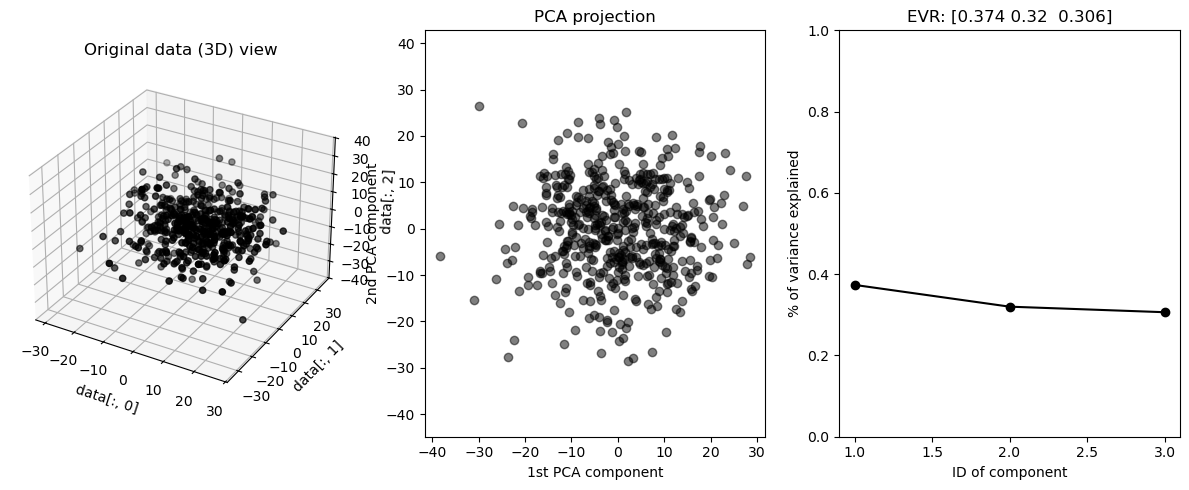

In [12]:
pca_show(data_triangle(noise=10), 'Triangle, noise=10')

Dane dwuwymiarowe, znormalizowane przez PCA ("whitened"):

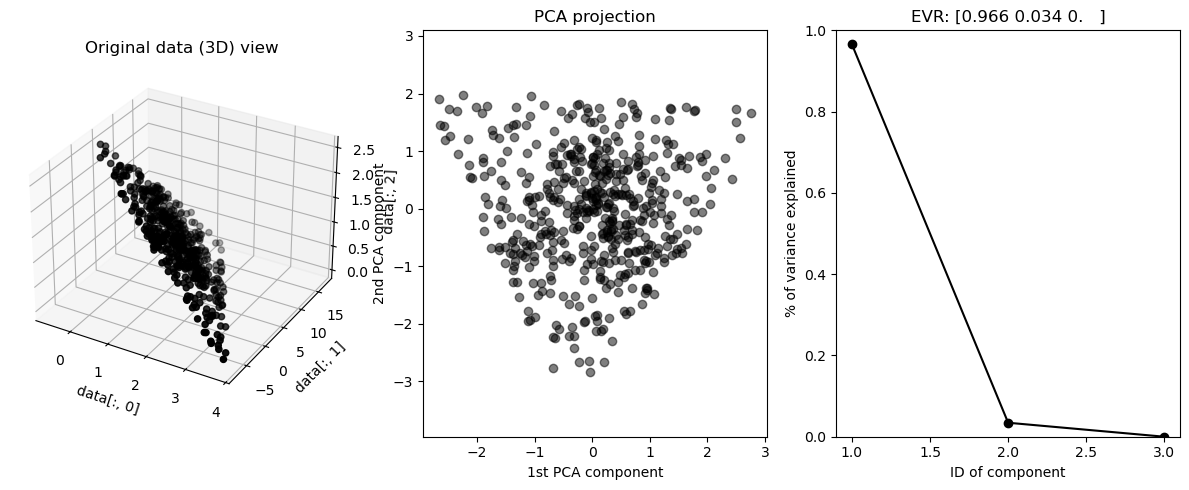

In [13]:
pca_show(data_triangle(), 'Triangle (whitened)', whiten=True)